In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from math import sqrt
import time
import re
from scipy import signal
import ipywidgets as widgets
from src.analisi.tools import *
import emcee
import scipy as sp

In [2]:
%matplotlib widget
plt.close('all')

In [3]:
# selettore cartella
folder_selector = widgets.Dropdown( 
    options=sorted([f for f in os.listdir(base_img_folder) if os.path.isdir(os.path.join(base_img_folder, f))], reverse=True),
    description='Sessione:',
    style={'description_width': 'initial'}
)

display(folder_selector)

Dropdown(description='Sessione:', options=('percolazione', 'lampadina_test_final', 'lampadina3_test', 'lampadi…

# Misure di spessore e rate della bilancia

In [4]:
# caricamento dati
data_folder = os.path.join(base_img_folder, folder_selector.value)
image_folder = os.path.join(data_folder, "images")
bilancia_file = os.path.join(data_folder, "data", "points.txt")

bilancia_timestamps, bilancia_thicknesses, bilancia_rates = load_bilancia_data(bilancia_file)
bilancia_trel = np.array(bilancia_timestamps) - bilancia_timestamps[0]  # secondi dall'inizio della misura

# convertiamo in array numpy per comodità
bilancia_thicknesses = np.array(bilancia_thicknesses)   # spessori letti dalla bilancia
bilancia_rates = np.array(bilancia_rates)   # rate di deposizione letti dalla bilancia

# tagliamo i primi 100 secondi, hanno spessore costante
start_cut_time = 100
cut_mask = bilancia_trel >= start_cut_time
bilancia_trel = bilancia_trel[cut_mask]
bilancia_thicknesses = bilancia_thicknesses[cut_mask]
bilancia_rates = bilancia_rates[cut_mask]

In [5]:
# fit lineare per ottenere la funzione di spessore in funzione del tempo
fitted_rate, thickness_offset = np.polyfit(bilancia_trel, bilancia_thicknesses, 1)  # rate medio e offset per spessore vs tempo
spessori_func = lambda t: fitted_rate*t + thickness_offset  # funzione di spessore in funzione del tempo, più comoda rispetto a portarsi dietro tutti i dati della bilancia
fitted_rate_residues = bilancia_thicknesses - spessori_func(bilancia_trel)  # residui del fit lineare
fitted_rate_std = np.std(abs(fitted_rate_residues))  # deviazione standard dei residui del fit lineare
fitted_rate_std_offset = np.mean(abs(fitted_rate_residues))  # offset dei residui del fit lineare

# calcolo degli spessori come integrale dei rate
spessori_from_rate = np.cumsum(bilancia_rates * np.diff(np.concatenate(([0], bilancia_trel))), axis=0)  # integrale dei rate per ottenere lo spessore, con np.diff per calcolare i delta_t tra i campioni

print(f"Spessore finale da bilancia: {bilancia_thicknesses[-1]:.6f} m")
print(f"Spessore finale da rate: {spessori_from_rate[-1]:.6f} m")
print(f"Spessore finale da fit lineare: {spessori_func(bilancia_trel[-1]):.6f} m")

# fit lineare tra spessori da rate e spessori da bilancia per ottenere il fattore di scala e l'offset
non_zero_mask = (spessori_from_rate > 0) & (bilancia_thicknesses > 0)
unit_m, unit_q = np.polyfit(bilancia_thicknesses[non_zero_mask], spessori_from_rate[non_zero_mask], 1)
spessori_from_rate_scaled = unit_m * bilancia_thicknesses + unit_q  # spessori da rate scalati per confronto con spessori da bilancia

print(f"Fattore di scala per spessore da rate: {unit_m:.6f}")
print(f"Offset per spessore da rate: {unit_q:.6f}")


Spessore finale da bilancia: 4.836000 m
Spessore finale da rate: 2122.215020 m
Spessore finale da fit lineare: 4.970419 m
Fattore di scala per spessore da rate: 440.059544
Offset per spessore da rate: -6.667975


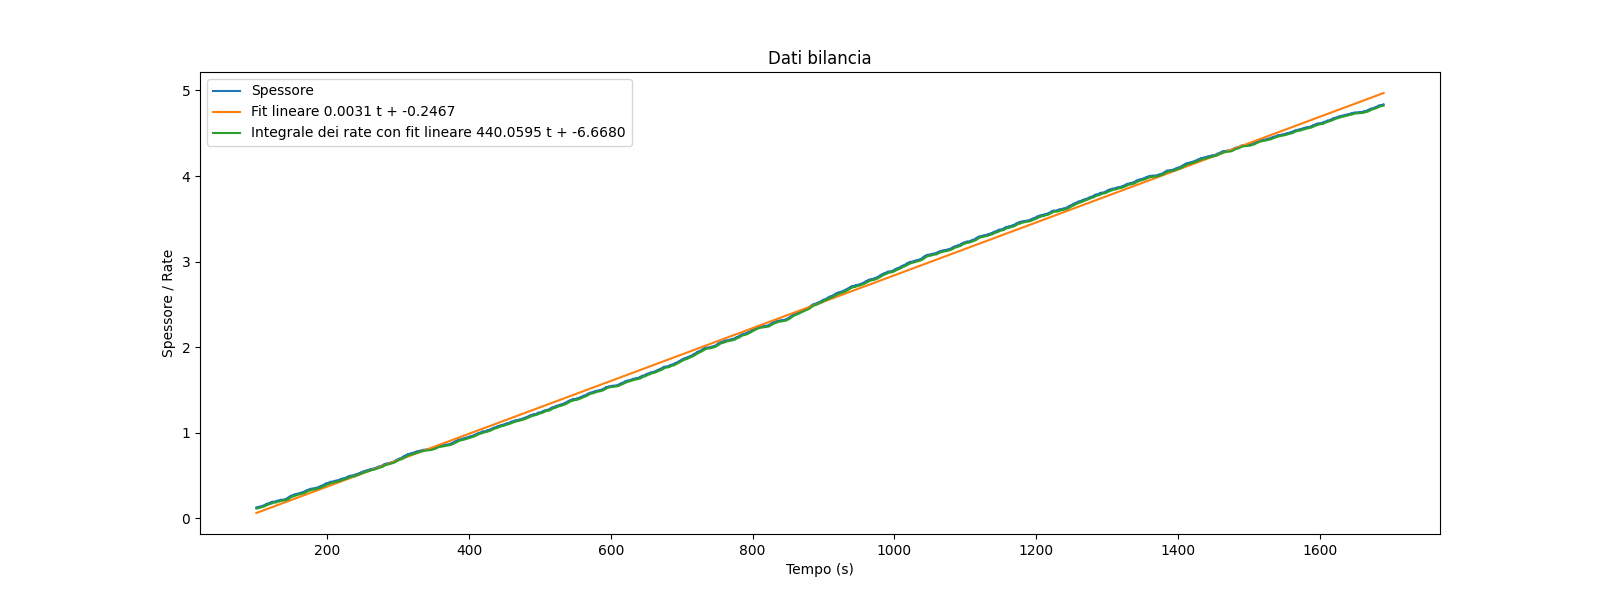

In [6]:
# plot dei dati della bilancia e confronto con spessori da rate e fit lineare
plt.figure(figsize=(16, 6))

plt.plot(bilancia_trel, bilancia_thicknesses, label='Spessore')
plt.plot(bilancia_trel, spessori_func(bilancia_trel), label=f'Fit lineare {fitted_rate:.4f} t + {thickness_offset:.4f}')
plt.plot(bilancia_trel, spessori_from_rate / unit_m, label=f'Integrale dei rate con fit lineare {unit_m:.4f} t + {unit_q:.4f}')

plt.xlabel('Tempo (s)')
plt.ylabel('Spessore / Rate')
plt.title('Dati bilancia')
plt.legend()

plt.show()

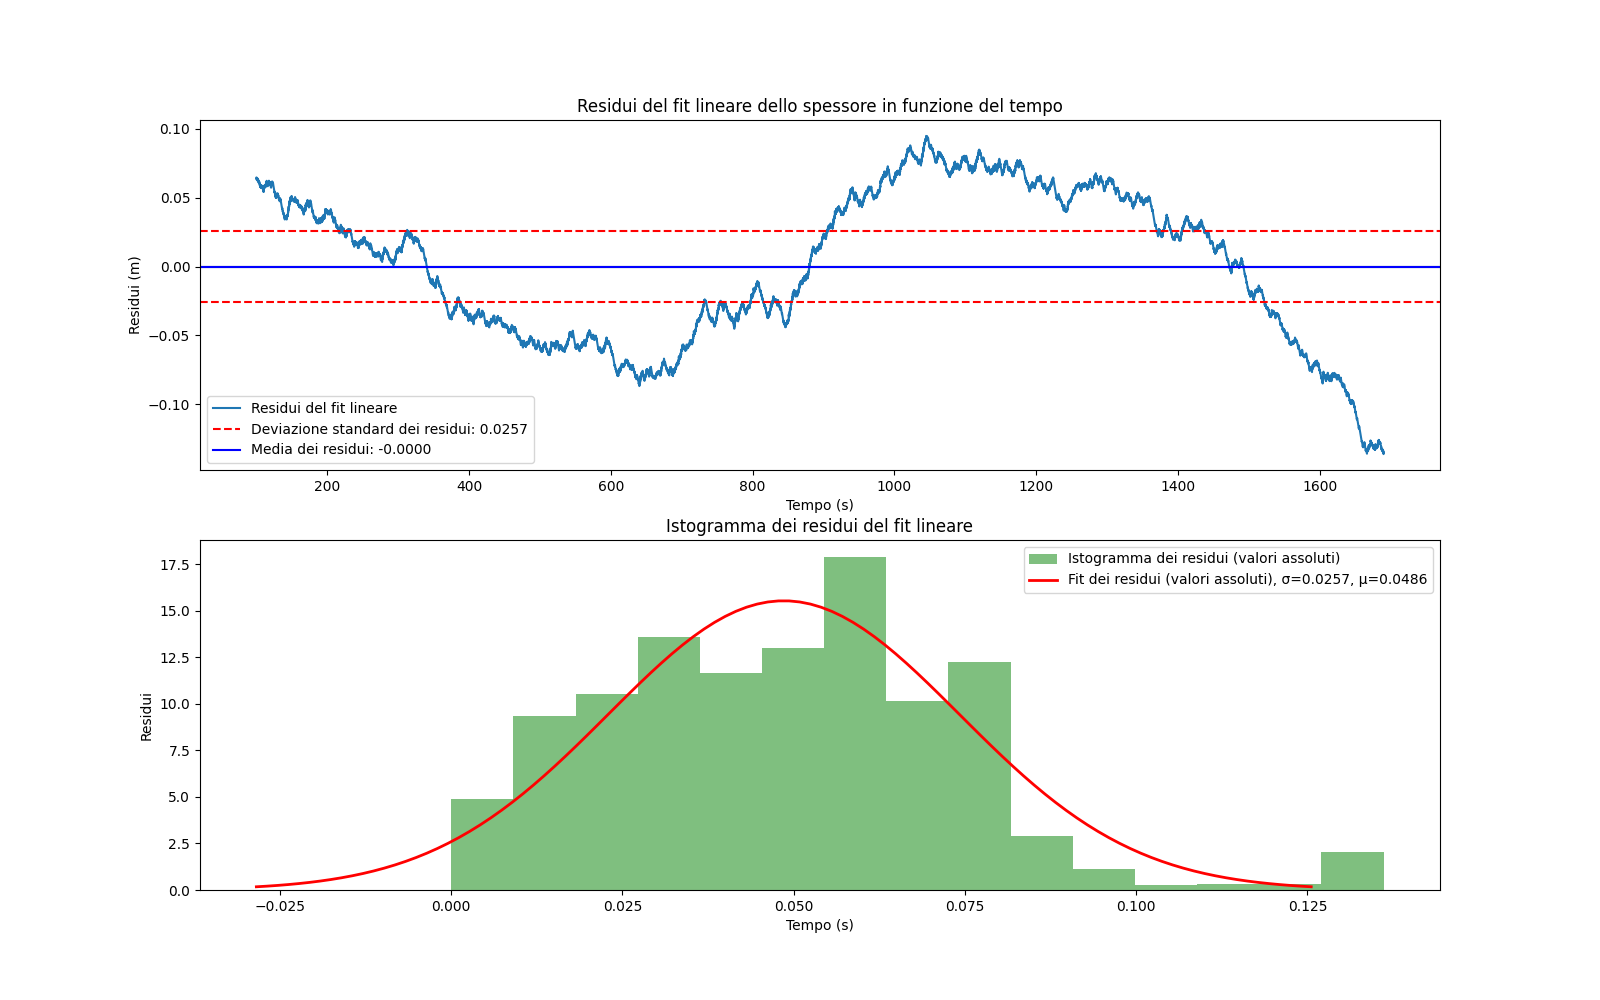

In [7]:
# plot dei residui del fit lineare, con deviazione standard dei residui
plt.figure(figsize=(16, 10))

plt.subplot(2, 1, 1)

plt.title('Residui del fit lineare dello spessore in funzione del tempo')
plt.plot(bilancia_trel, fitted_rate_residues, label='Residui del fit lineare')

plt.axhline(fitted_rate_std, color='r', linestyle='--', label=f'Deviazione standard dei residui: {fitted_rate_std:.4f}')
plt.axhline(-fitted_rate_std, color='r', linestyle='--')

plt.axhline(0, color='k', linestyle='-')
plt.axhline(np.mean(fitted_rate_residues), color='b', linestyle='-', label=f'Media dei residui: {np.mean(fitted_rate_residues):.4f}')

plt.xlabel('Tempo (s)')
plt.ylabel('Residui (m)')
plt.legend()

plt.subplot(2, 1, 2)
plt.title('Istogramma dei residui del fit lineare')
plt.hist(abs(fitted_rate_residues), bins=15, density=True, alpha=0.5, label='Istogramma dei residui (valori assoluti)', color='g')

xs = np.linspace(-3*fitted_rate_std + fitted_rate_std_offset, 3*fitted_rate_std + fitted_rate_std_offset, 100)
ys = (1 / (fitted_rate_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((fitted_rate_std_offset - xs) / fitted_rate_std) ** 2)
plt.plot(xs, ys, color='r', label=f'Fit dei residui (valori assoluti), σ={fitted_rate_std:.4f}, μ={fitted_rate_std_offset:.4f}', linewidth=2)


plt.xlabel('Tempo (s)')
plt.ylabel('Residui')
plt.legend()
plt.show()

In [8]:
# ipotizzando rate distribuiti come una gaussiana attorno alla media
rates_mean = np.mean(bilancia_rates)
rates_std = np.std(bilancia_rates)

rates_distribution = lambda x, A=1: A * (1 / (rates_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - rates_mean) / rates_std) ** 2)    # fit della distribuzione dei rate come gaussiana, A è l'ampiezza della gaussiana | Normalizzazione della distribuzione dei rate

print(f"Media delle rate: {rates_mean:.2f}")
print(f"Deviazione standard delle rate: {rates_std:.2f}")

Media delle rate: 1.30
Deviazione standard delle rate: 0.65


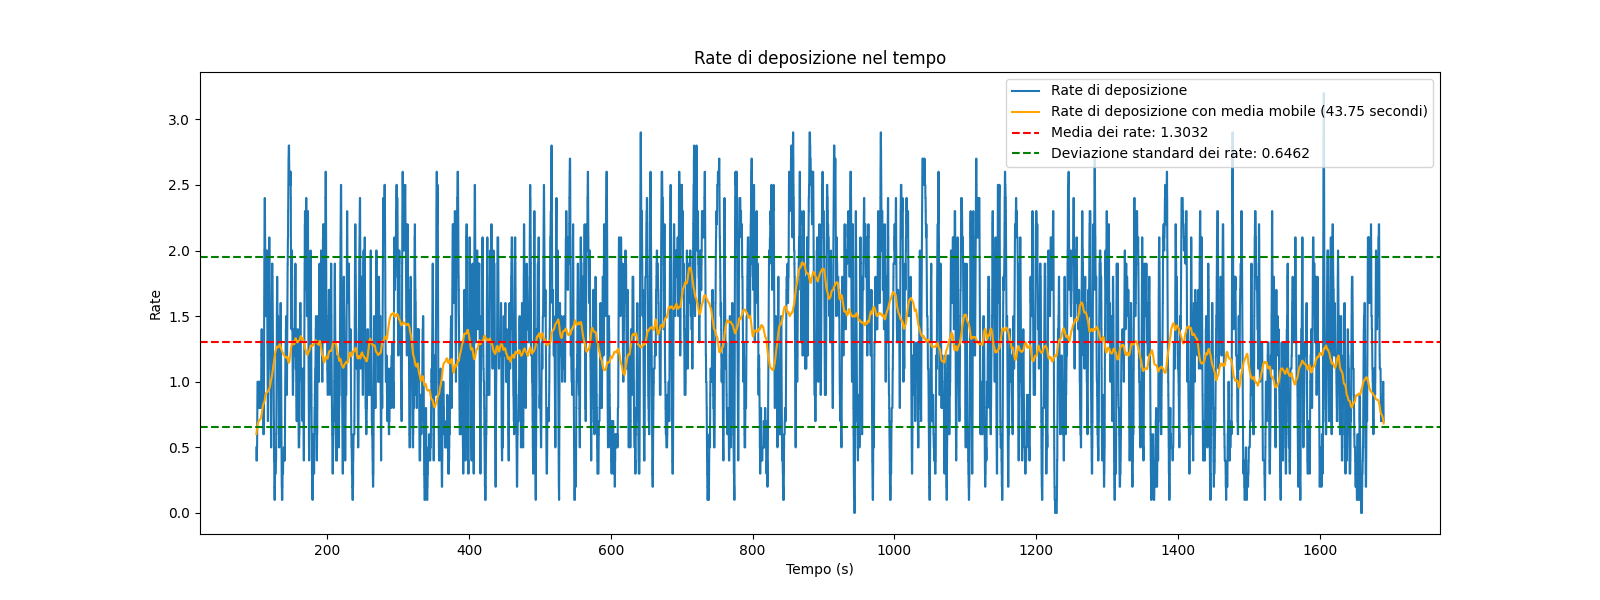

In [9]:
# plot del rate nel tempo
plt.figure(figsize=(16, 6))
plt.plot(bilancia_trel, bilancia_rates, label='Rate di deposizione')

window_size = 1000  # dimensione della finestra per la media mobile
avg_sample_rate = np.mean(np.diff(bilancia_trel))  # calcola il rate medio di campionamento
window_size_seconds = window_size * avg_sample_rate  # converte la dimensione della finestra in secondi
rate_smooth = signal.convolve(bilancia_rates, np.ones(window_size)/window_size, mode='same')  # media mobile per smoothing
plt.plot(bilancia_trel, rate_smooth, label=f'Rate di deposizione con media mobile ({window_size_seconds:.2f} secondi)', color='orange')

# media dei rate e deviazione standard
plt.axhline(rates_mean, color='r', linestyle='--', label=f'Media dei rate: {rates_mean:.4f}')
plt.axhline(rates_mean + rates_std, color='g', linestyle='--', label=f'Deviazione standard dei rate: {rates_std:.4f}')
plt.axhline(rates_mean - rates_std, color='g', linestyle='--')

plt.xlabel('Tempo (s)')
plt.ylabel('Rate')
plt.title('Rate di deposizione nel tempo')
plt.legend()
plt.show()

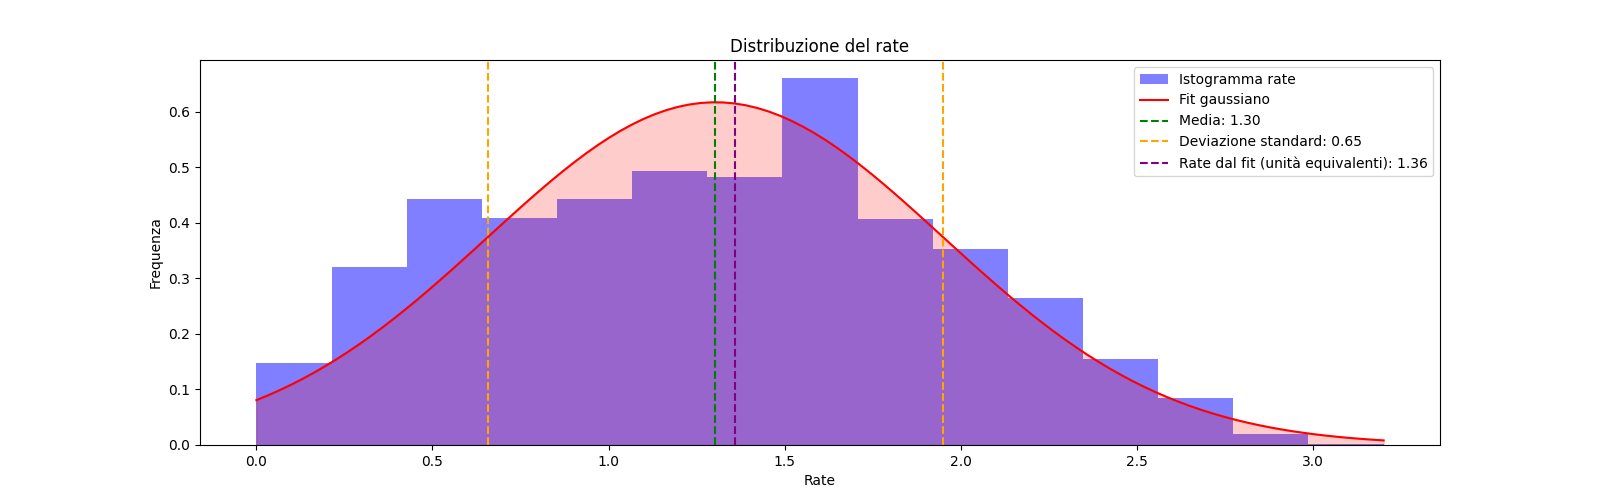

In [10]:
# plot dell'istogramma dei rate con fit gaussiano e confronto con risultati da spessore vs tempo e integrale dei rate

plt.figure(figsize=(16, 5))

# istogramma dei rate
plt.hist(bilancia_rates, bins=15, density=True, alpha=0.5, label='Istogramma rate', color='blue')

# fit gaussiano
xs = np.linspace(min(bilancia_rates), max(bilancia_rates), 100)
plt.plot(xs, rates_distribution(xs), label='Fit gaussiano', color='red')
plt.fill_between(xs, rates_distribution(xs), color='red', alpha=0.2)

# media e deviazione standard
plt.axvline(rates_mean, color='green', linestyle='--', label=f'Media: {rates_mean:.2f}')
plt.axvline(rates_mean + rates_std, color='orange', linestyle='--', label=f"Deviazione standard: {rates_std:.2f}")
plt.axvline(rates_mean - rates_std, color='orange', linestyle='--')

# rate da fit lineare spessore vs tempo
plt.axvline(fitted_rate * unit_m, color='purple', linestyle='--', label=f'Rate dal fit (unità equivalenti): {fitted_rate * unit_m:.2f}')

# deviazione dei residui del fit lineare
#plt.axvline(fitted_rate_std * unit_m, color='brown', linestyle='--', label=f'dev_std residui fit lineare: {fitted_rate_std * unit_m:.2f}')
#plt.axvline(-fitted_rate_std * unit_m, color='brown', linestyle='--')

plt.legend()
plt.xlabel('Rate')
plt.ylabel('Frequenza')
plt.title('Distribuzione del rate')

plt.show()


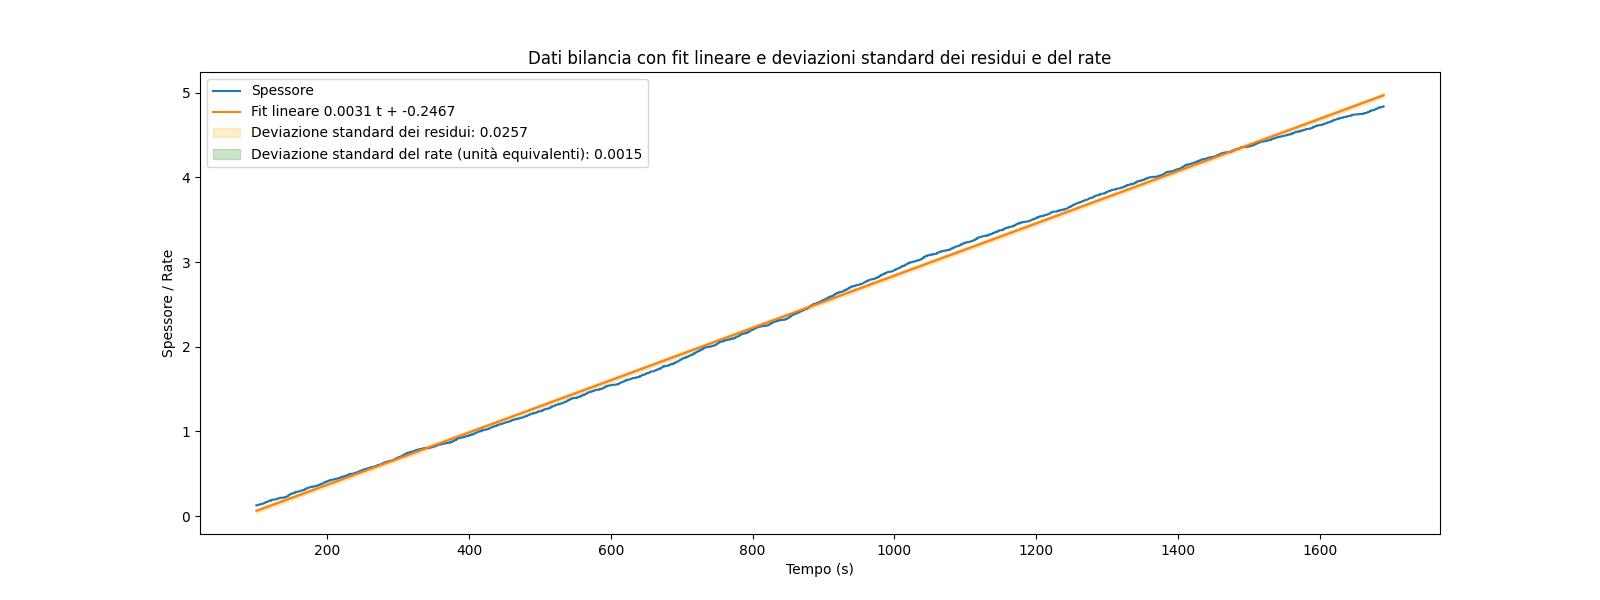

In [11]:
# plot del fit e dei dati, con dev std dei residui e con dev std del rate
plt.figure(figsize=(16, 6))

plt.plot(bilancia_trel, bilancia_thicknesses, label='Spessore')

plt.plot(bilancia_trel, spessori_func(bilancia_trel), label=f'Fit lineare {fitted_rate:.4f} t + {thickness_offset:.4f}')

residues_error_upper = spessori_func(bilancia_trel) + fitted_rate_std
residues_error_lower = spessori_func(bilancia_trel) - fitted_rate_std
plt.fill_between(bilancia_trel, residues_error_lower, residues_error_upper, color='orange', alpha=0.2, label=f'Deviazione standard dei residui: {fitted_rate_std:.4f}')

rate_variance_upper = spessori_func(bilancia_trel) + rates_std /unit_m
rate_variance_lower = spessori_func(bilancia_trel) - rates_std / unit_m
plt.fill_between(bilancia_trel, rate_variance_lower, rate_variance_upper, color='green', alpha=0.2, label=f'Deviazione standard del rate (unità equivalenti): {rates_std / unit_m:.4f}')

plt.xlabel('Tempo (s)')
plt.ylabel('Spessore / Rate')
plt.title('Dati bilancia con fit lineare e deviazioni standard dei residui e del rate')
plt.legend()
plt.show()

# Coverage?

Sto cercando di capire come il coverage (filling factor) dipenda dallo spessore medio del campione.

L'idea sarebbe di trovare la forma della funzione coverage(spessore) da dei semplici monte carlo, simulando la deposizione di particelle su un piano sotto diverse ipotesi.

In [12]:
# simulazioni monte carlo molto schematiche per vedere diverse funzioni spessore <-> coverage sotto diverse ipotesi
from skimage.measure import label

def spessore_campione(altezze):
    return np.mean(altezze)

def coverage(field, threshold=0.5):
    """
    Calcola il coverage di un campo 2D dato un threshold. Restituisce la frazione di pixel sopra il threshold.
    """

    return float((field > threshold).mean())

def percolates(mask):
    """
    Controlla se un campione percola da sinistra a destra. Restituisce True se percola, False altrimenti.
    """
    lbl = label(mask)
    left  = set(np.unique(lbl[:, 0]).tolist()) - {0}
    right = set(np.unique(lbl[:, -1]).tolist()) - {0}
    return bool(left & right)

percolation_threshold = 0.5  # soglia per considerare un campione percolante

In [13]:
def deposit_disks(substrate_size=512, disk_radius=8, n_disks=4000, n_checkpoints=60):

    sample = np.zeros((substrate_size, substrate_size), dtype=np.uint16)
    checkpoints = set(np.unique(np.linspace(1, n_disks, n_checkpoints).astype(int)).tolist())
    snapshots, N_list = [], []

    for n in range(1, n_disks + 1):
        
        deposit = np.zeros_like(sample)
        X, Y = np.meshgrid(np.arange(substrate_size), np.arange(substrate_size))

        cx, cy = np.random.randint(0, substrate_size, size=2)
        distances_from_center = np.sqrt((X - cx)**2 + (Y - cy)**2)
        disk_mask = distances_from_center <= disk_radius
        deposit[disk_mask] = 1

        sample += deposit

        if n in checkpoints:
            snapshots.append(sample.copy())
            N_list.append(n)
    
    return np.array(N_list), snapshots, dict(substrate_size=substrate_size, disk_radius=disk_radius)
        
def deposit_gaussians(substrate_size=512, sigma=8, n_gaussians=4000, n_checkpoints=60):

    sample = np.zeros((substrate_size, substrate_size), dtype=np.float32)
    checkpoints = set(np.unique(np.linspace(1, n_gaussians, n_checkpoints).astype(int)).tolist())
    snapshots, N_list = [], []

    for n in range(1, n_gaussians + 1):
        
        deposit = np.zeros_like(sample)
        X, Y = np.meshgrid(np.arange(substrate_size), np.arange(substrate_size))

        cx, cy = np.random.randint(0, substrate_size, size=2)
        gaussian_mask = np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))
        deposit += gaussian_mask

        sample += deposit

        if n in checkpoints:
            snapshots.append(sample.copy())
            N_list.append(n)
    
    return np.array(N_list), snapshots, dict(substrate_size=substrate_size, sigma=sigma)
    
def deposit_single_atoms(substrate_size=512, n_atoms=4000, n_checkpoints=60):

    sample = np.zeros((substrate_size, substrate_size), dtype=np.uint16)
    checkpoints = set(np.unique(np.linspace(1, n_atoms, n_checkpoints).astype(int)).tolist())
    snapshots, N_list = [], []

    for n in range(1, n_atoms + 1):
        
        for _ in range(100):
            cx, cy = np.random.randint(0, substrate_size, size=2)
            sample[cy, cx] += 1

        if n in checkpoints:
            snapshots.append(sample.copy())
            N_list.append(n)
    
    return np.array(N_list), snapshots, dict(substrate_size=substrate_size)

mc_results = {
    "dischi" : deposit_disks(substrate_size=512, disk_radius=8, n_disks=4000, n_checkpoints=100),
    "gaussiane" : deposit_gaussians(substrate_size=512, sigma=8, n_gaussians=4000, n_checkpoints=100),
    "singoli_atomi" : deposit_single_atoms(substrate_size=512, n_atoms=4000, n_checkpoints=100)
}

Valore analitico di N0 per dischi: 1303.80


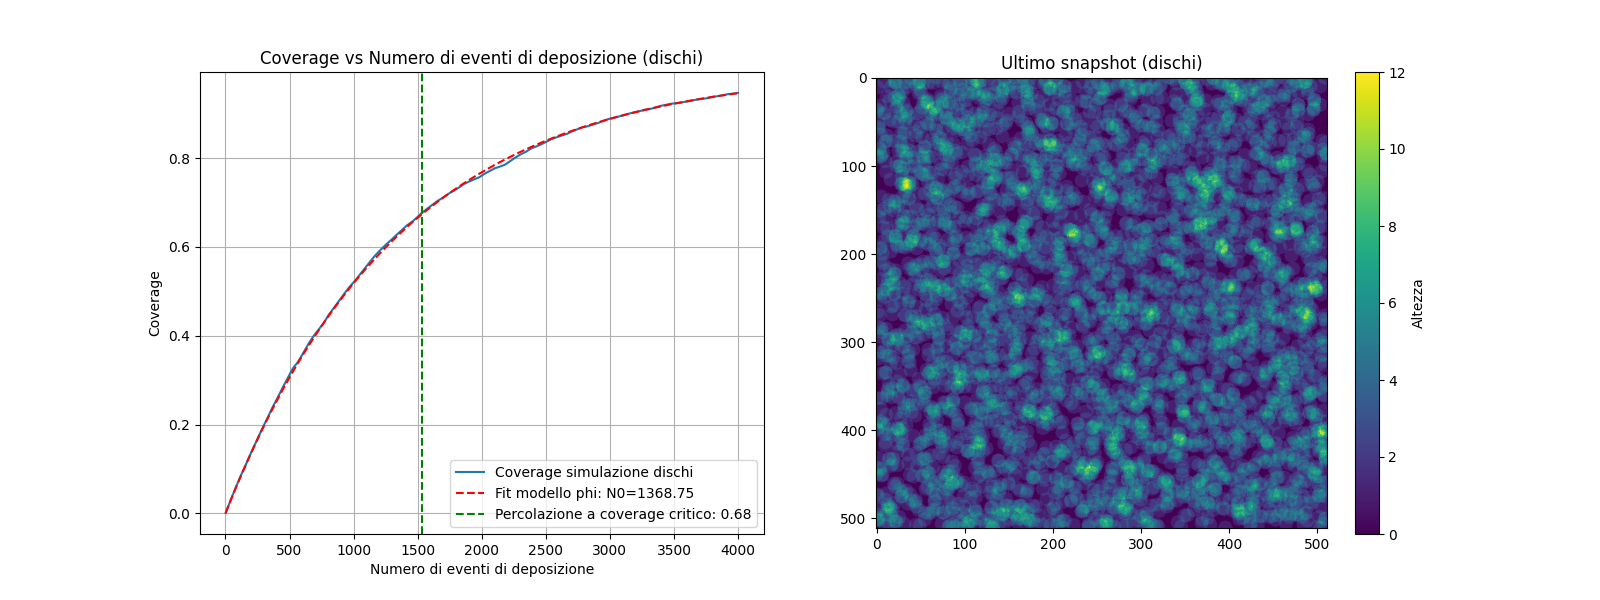

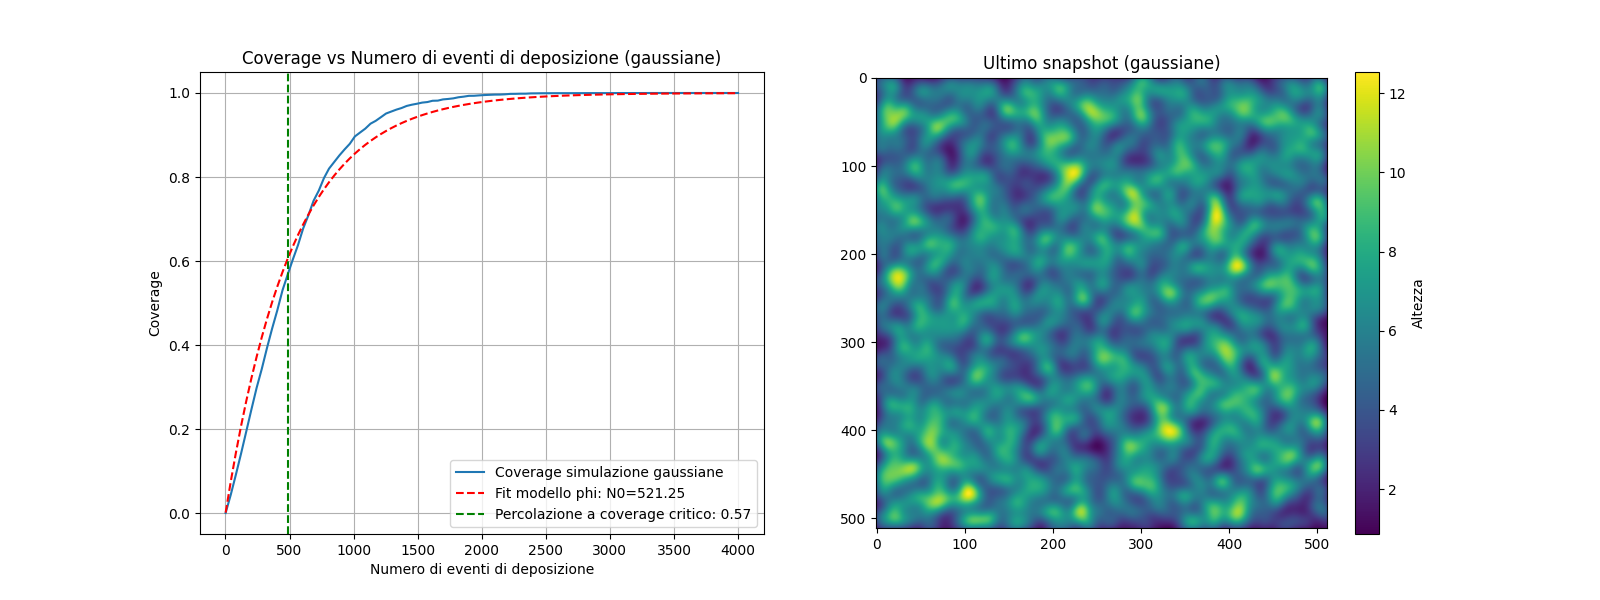

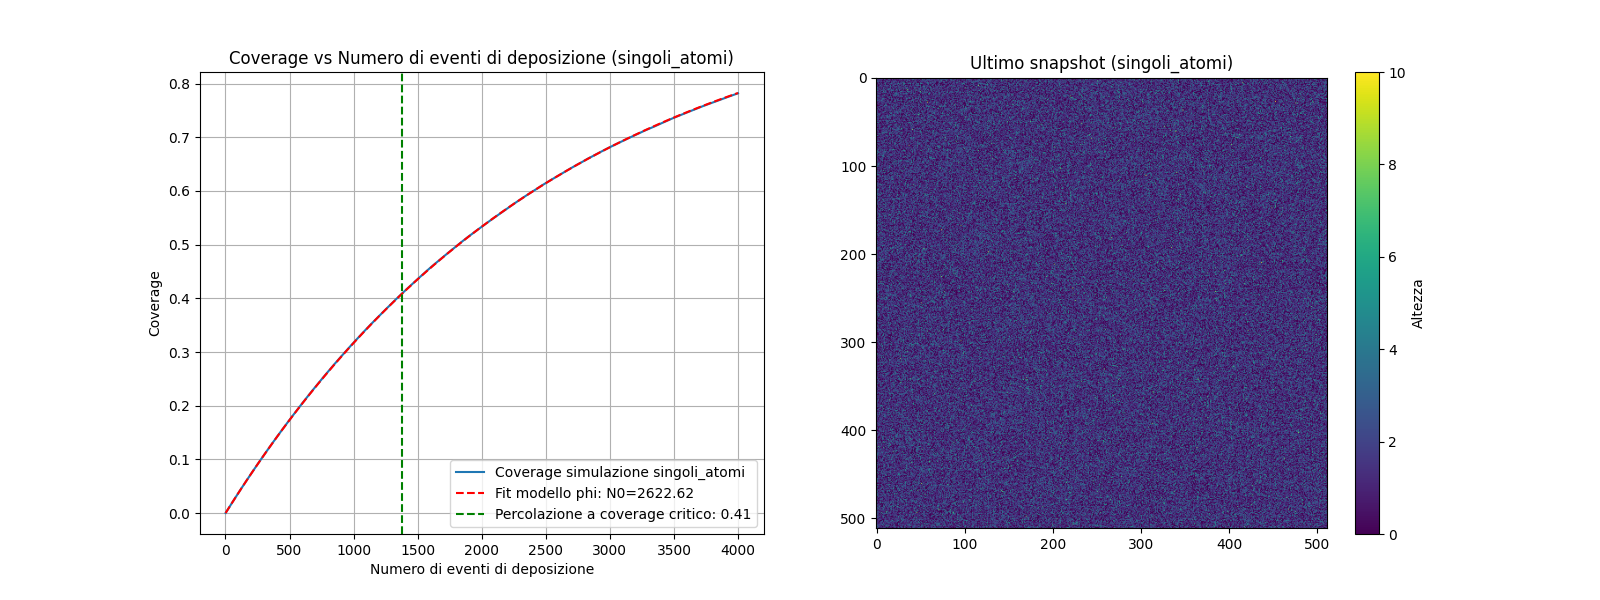

In [14]:
def phi_model(N, N0):
    return 1 - np.exp(-N / N0)

phi_critical_estimates = {}

for key, (N_list, snapshots, params) in mc_results.items():

    coverages = [coverage(snap) for snap in snapshots]
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)

    plt.plot(N_list, coverages, label=f'Coverage simulazione {key}')
    
    if key == 'dischi':
        N0_ana = params["substrate_size"]**2 / (np.pi * params['disk_radius']**2)
        print(f"Valore analitico di N0 per dischi: {N0_ana:.2f}")

    # Fit del modello phi_model ai dati di coverage
    popt, pcov = sp.optimize.curve_fit(phi_model, N_list, coverages)
    N0_fit = popt[0]
    plt.plot(N_list, phi_model(N_list, N0_fit), 'r--', label=f'Fit modello phi: N0={N0_fit:.2f}')

    for i, snap in enumerate(snapshots):
        if percolates(snap > percolation_threshold):
            plt.axvline(N_list[i], color='g', linestyle='--', label=f'Percolazione a coverage critico: {coverage(snap):.2f}')
            phi_critical_estimates[key] = coverage(snap)
            break
    
    plt.xlabel('Numero di eventi di deposizione')
    plt.ylabel('Coverage')
    plt.title(f'Coverage vs Numero di eventi di deposizione ({key})')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.imshow(snapshots[-1], cmap='viridis')
    plt.title(f'Ultimo snapshot ({key})')
    plt.colorbar(label='Altezza')


    plt.show()


# Percolazione

In [15]:
# caricamento dati di corrente
elettrometro_dir = os.path.join(base_img_folder, folder_selector.value, 'data/points_keithley.txt')
keithley_currents, keithley_timestamps, keithley_ranges = load_keithley_data(elettrometro_dir)

keithley_currents = np.array(keithley_currents)
keithley_timestamps = np.array(keithley_timestamps)
keithley_trel = keithley_timestamps - keithley_timestamps[0]

In [16]:
# separazione dei 3 range acquisiti
auto_range_indices = np.array([i for i, r in enumerate(keithley_ranges) if r == -1])
plus2_inds = auto_range_indices - 1
plus1_inds = auto_range_indices - 2

elettrometro_masks = {
    "auto" : auto_range_indices,
    "+2" : plus2_inds,
    "+1" : plus1_inds
}



In [17]:
# impostiamo a 0 i valori non sensati (NaN e molto grandi)
keithley_currents = np.nan_to_num(keithley_currents, nan=0.0, posinf=0.0, neginf=0.0)
keithley_trel = np.nan_to_num(keithley_trel, nan=0.0, posinf=0.0, neginf=0.0)

max_current = 1e-1  # Soglia massima di corrente (in A)
keithley_currents[np.abs(keithley_currents) > max_current] = 0.0

In [18]:
# compute the median and the standard deviation of the current values between the 3 ranges

range_auto = keithley_currents[elettrometro_masks["auto"]]
range1 = keithley_currents[elettrometro_masks["+1"]]
range2 = keithley_currents[elettrometro_masks["+2"]]

In [19]:
# sezioni identificate dal grafico, da usare per trattare separatamente le regioni in base a cosa da valori più ragionevoli
section_cuts = {
    "flat_start" : 1920,    # all'inizio tutte e 3 le serie sono piatte a 0, quindi ok
    "+2 correct (continuity)" : 1985,   # in questa sezione le 3 serie danno valori diversi. Imponendo che la curva debba essere continua, la serie +2 è quella più coerente con l'andamento a lungo termine
    "exclude auto" : 2021,  # in questa sezione la serie auto diverge rispetto alle altre due e da valori che darebbero una curva non continua
    "fit_cut" : 2400,  # in questo punto tagliamo i dati usati per il fit. Il motivo è semplicemente che abbiamo troppi dati e prenderli tutti rischia di far tendere il modello a una retta
    "fit_initial_cut" : 1400  # in questo punto tagliamo i dati iniziali usati per il fit
}

In [20]:
# separiamo i dati per ricombinarli in un unico array, usando i dati più affidabili per ogni sezione di tempo
auto_data = keithley_currents[elettrometro_masks["auto"]]
auto_ts = keithley_trel[elettrometro_masks["auto"]]

one_data = keithley_currents[elettrometro_masks["+1"]]
one_ts = keithley_trel[elettrometro_masks["+1"]]

two_data = keithley_currents[elettrometro_masks["+2"]]
two_ts = keithley_trel[elettrometro_masks["+2"]]

combined_ts = np.mean([auto_ts, one_ts, two_ts], axis=0)  # media dei timestamp per avere un array unico di timestamp
combined_data = np.zeros_like(keithley_currents[elettrometro_masks["auto"]])

# prima del primo taglio tutte e 3 le serie danno gli stessi valori, quindi possiamo prendere la media tra le 3 serie
combined_data[combined_ts <= section_cuts["flat_start"]] = np.mean([auto_data[combined_ts <= section_cuts["flat_start"]], one_data[combined_ts <= section_cuts["flat_start"]], two_data[combined_ts <= section_cuts["flat_start"]]], axis=0)

# tra il primo e il secondo taglio, la serie +2 è quella più coerente con l'andamento a lungo termine
combined_data[(combined_ts > section_cuts["flat_start"]) & (combined_ts <= section_cuts["+2 correct (continuity)"])] = two_data[(two_ts > section_cuts["flat_start"]) & (two_ts <= section_cuts["+2 correct (continuity)"])]

# tra il secondo e il terzo taglio, la serie auto è da escludere, le altre due vanno bene. Per semplicità, prendiamo la media tra le due serie rimanenti
combined_data[(combined_ts > section_cuts["+2 correct (continuity)"]) & (combined_ts <= section_cuts["exclude auto"])] = np.mean([one_data[(one_ts > section_cuts["+2 correct (continuity)"]) & (one_ts <= section_cuts["exclude auto"])], two_data[(two_ts > section_cuts["+2 correct (continuity)"]) & (two_ts <= section_cuts["exclude auto"])]], axis=0)

# dal terzo raglio in poi le serie sembrano tutte dare valori simili, quindi possiamo prendere la media tra le 3 serie
combined_data[combined_ts > section_cuts["exclude auto"]] = np.mean([auto_data[combined_ts > section_cuts["exclude auto"]], one_data[combined_ts > section_cuts["exclude auto"]], two_data[combined_ts > section_cuts["exclude auto"]]], axis=0)


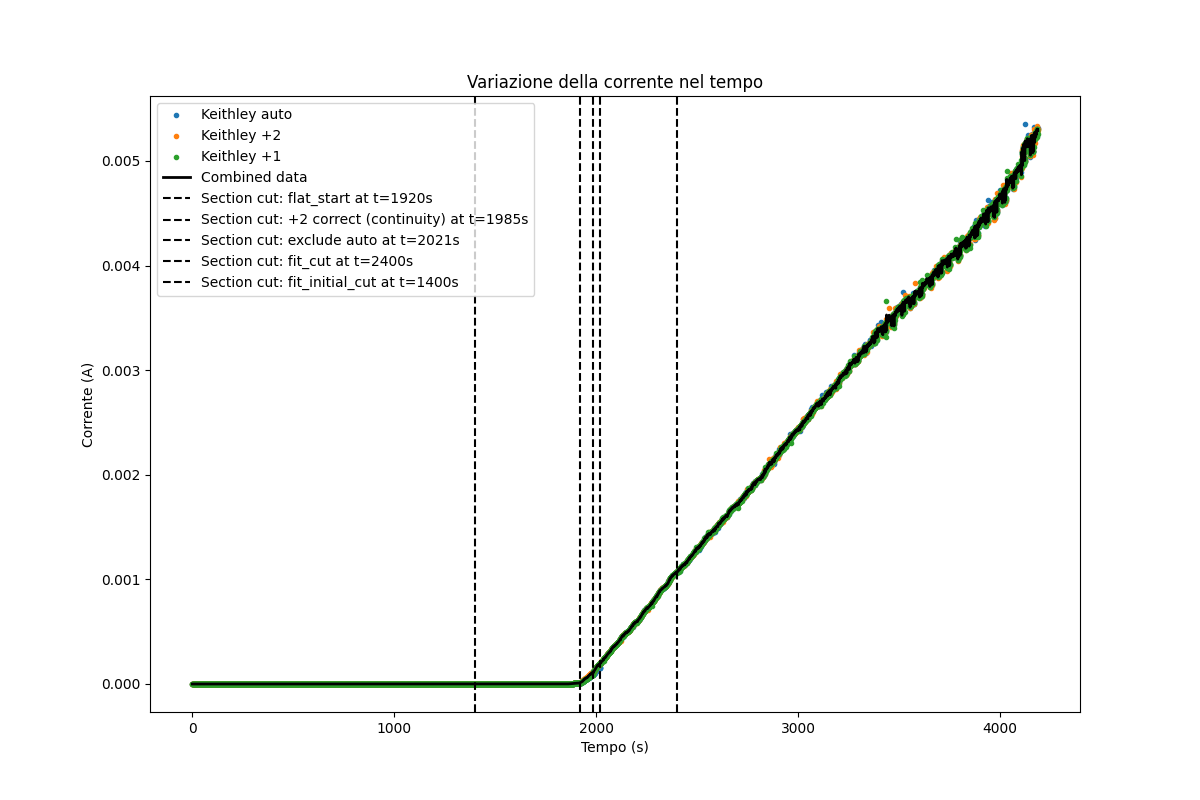

In [21]:
# plot resistenze nel tempo, con i tagli delle sezioni e le serie separate per range

plt.figure(figsize=(12, 8))

for name, mask in elettrometro_masks.items():
    plt.plot(keithley_trel[mask], keithley_currents[mask], label=f'Keithley {name}', marker='o', markersize=3, linestyle='none')

plt.plot(combined_ts, combined_data, label='Combined data', color='black', linewidth=2)

for section_name, section_cut in section_cuts.items():
    plt.axvline(section_cut, color='k', linestyle='--', label=f'Section cut: {section_name} at t={section_cut}s')

plt.xlabel('Tempo (s)')
plt.ylabel('Corrente (A)')
plt.title('Variazione della corrente nel tempo')
plt.legend()
plt.show()

In [22]:
# tagliamo i dati per il fit, usando solo la sezione tra fit_initial_cut e fit_cut
tempi_fit_mask = (combined_ts >= section_cuts["fit_initial_cut"]) & (combined_ts <= section_cuts["fit_cut"])
combined_ts_fit = combined_ts[tempi_fit_mask]
combined_data_fit = combined_data[tempi_fit_mask]

In [23]:
#H0 = 5.65  # spessore a cui il coverage raggiunge il 63% (1 - 1/e) secondo il modello di crescita esponenziale

def current_model_simple(h, A, p, hc):
    return A * np.maximum(h - hc, 0.0)**p

In [24]:
popt_simple, pcov_simple = sp.optimize.curve_fit(current_model_simple, spessori_func(combined_ts_fit), combined_data_fit, p0=[1e-9, 1.0, 0.5], bounds=([0, 0, 0], [np.inf, np.inf, np.inf]))

In [25]:
# dalla definizione di h0: h0​=hc/−ln(1−φc​), conosciamo il valore di φc stimato dalla simulazione di deposizione di dischi, quindi possiamo stimare h0 dal fit semplice

PHI_C = phi_critical_estimates["dischi"]  # valore di coverage critico stimato dalla simulazione di deposizione di dischi
H0 = popt_simple[2] / -np.log(1 - PHI_C)  # stima di H0 dal fit semplice, usando il valore di PHI_C stimato dalla simulazione di deposizione di dischi


print(f"Valore stimato di H0 dal fit semplice: {H0:.4f} m")

def current_model_phi(h, A, p):
    phi = 1 - np.exp(-h / H0)
    return A * np.maximum(phi - PHI_C, 0.0)**p

phi_from_h = lambda h: 1 - np.exp(-h / H0)  # funzione di coverage in funzione dello spessore, secondo il modello di crescita esponenziale
h_from_phi = lambda phi: -H0 * np.log(1 - phi)  # funzione inversa, spessore in funzione del coverage

popt_coverage, pcov_coverage = sp.optimize.curve_fit(current_model_phi, spessori_func(combined_ts_fit), combined_data_fit, p0=[1e-9, 1.0], bounds=([0, 0], [np.inf, np.inf]))

Valore stimato di H0 dal fit semplice: 5.0185 m


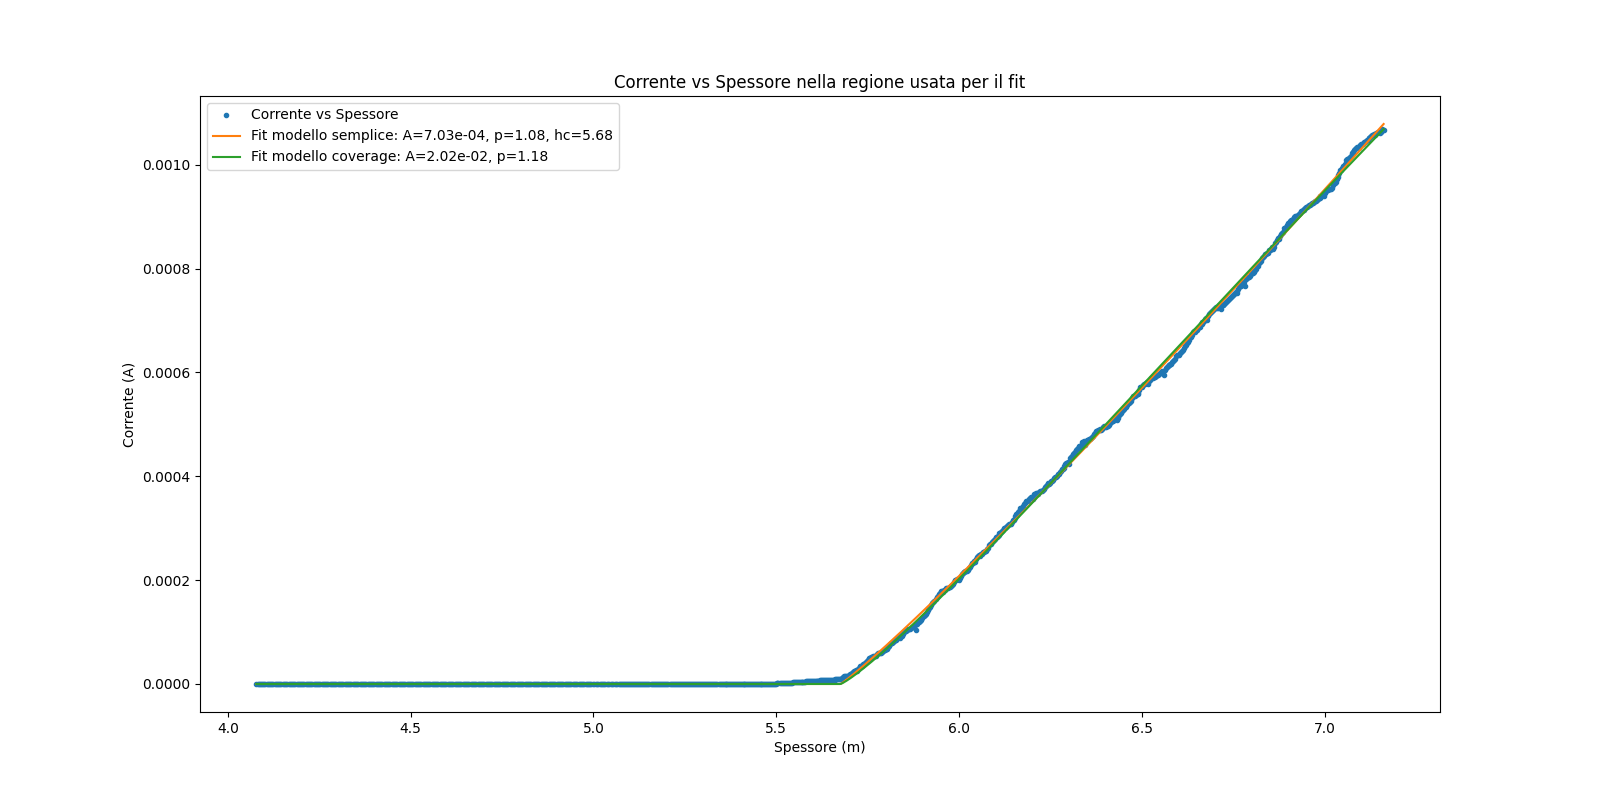

In [26]:
# plot di correnti vs spessore nella regione usata per il fit

plt.figure(figsize=(16, 8))

plt.plot(spessori_func(combined_ts_fit), combined_data_fit, label='Corrente vs Spessore', marker='o', markersize=3, linestyle='none')

# plot dei fit
h_fit = np.linspace(min(spessori_func(combined_ts_fit)), max(spessori_func(combined_ts_fit)), 1000)
plt.plot(h_fit, current_model_simple(h_fit, *popt_simple), label=f'Fit modello semplice: A={popt_simple[0]:.2e}, p={popt_simple[1]:.2f}, hc={popt_simple[2]:.2f}')
plt.plot(h_fit, current_model_phi(h_fit, *popt_coverage), label=f'Fit modello coverage: A={popt_coverage[0]:.2e}, p={popt_coverage[1]:.2f}')

plt.xlabel('Spessore (m)')
plt.ylabel('Corrente (A)')
plt.title('Corrente vs Spessore nella regione usata per il fit')
plt.legend()
plt.show()


In [27]:
phis = phi_from_h(spessori_func(combined_ts_fit))

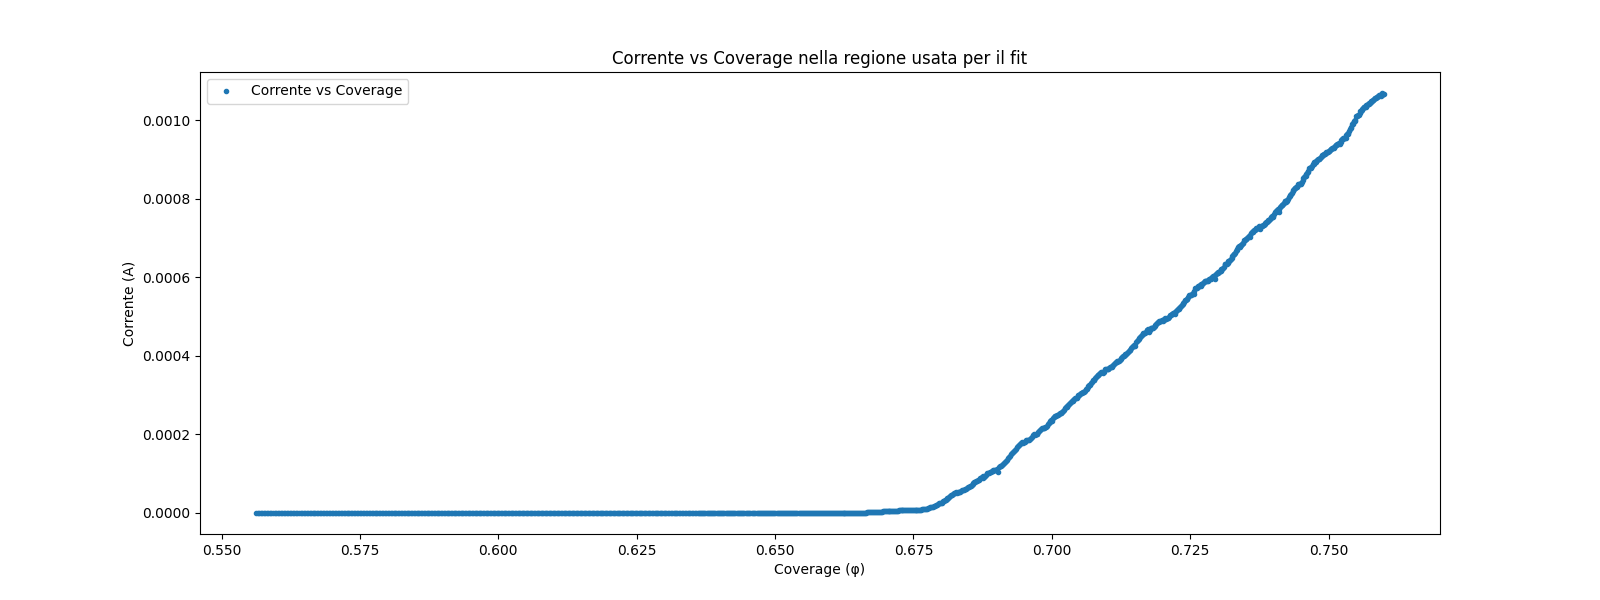

In [28]:
plt.figure(figsize=(16, 6))

plt.plot(phis, combined_data_fit, label='Corrente vs Coverage', marker='o', markersize=3, linestyle='none')

plt.title('Corrente vs Coverage nella regione usata per il fit')
plt.xlabel('Coverage (φ)')
plt.ylabel('Corrente (A)')
plt.legend()
plt.show()


In [29]:
# definiamo una funzione per calcolare il coverage dalla corrente, usando la funzione fittata

A = popt_coverage[0]
p = popt_coverage[1]

def calculate_coverage_from_current(current):
    phi = (current / A) ** (1 / p) + PHI_C
    return np.minimum(phi, 1.0)

# Dewetting

In [41]:
annealing_dir = "data/annealing"  # directory contenente i dati di annealing

#available_annealing_files = sorted([f for f in os.listdir(annealing_dir) if os.path.isfile(os.path.join(annealing_dir, f)) and f.endswith('.txt')])
annealing_resistence = np.loadtxt(os.path.join(annealing_dir, 'data_6nm_annealing.txt'))  # carica i dati di resistenza da file
annealing_temperature = np.loadtxt(os.path.join(annealing_dir, 'time_temp_6nm.txt'))  # carica i dati di temperatura da file


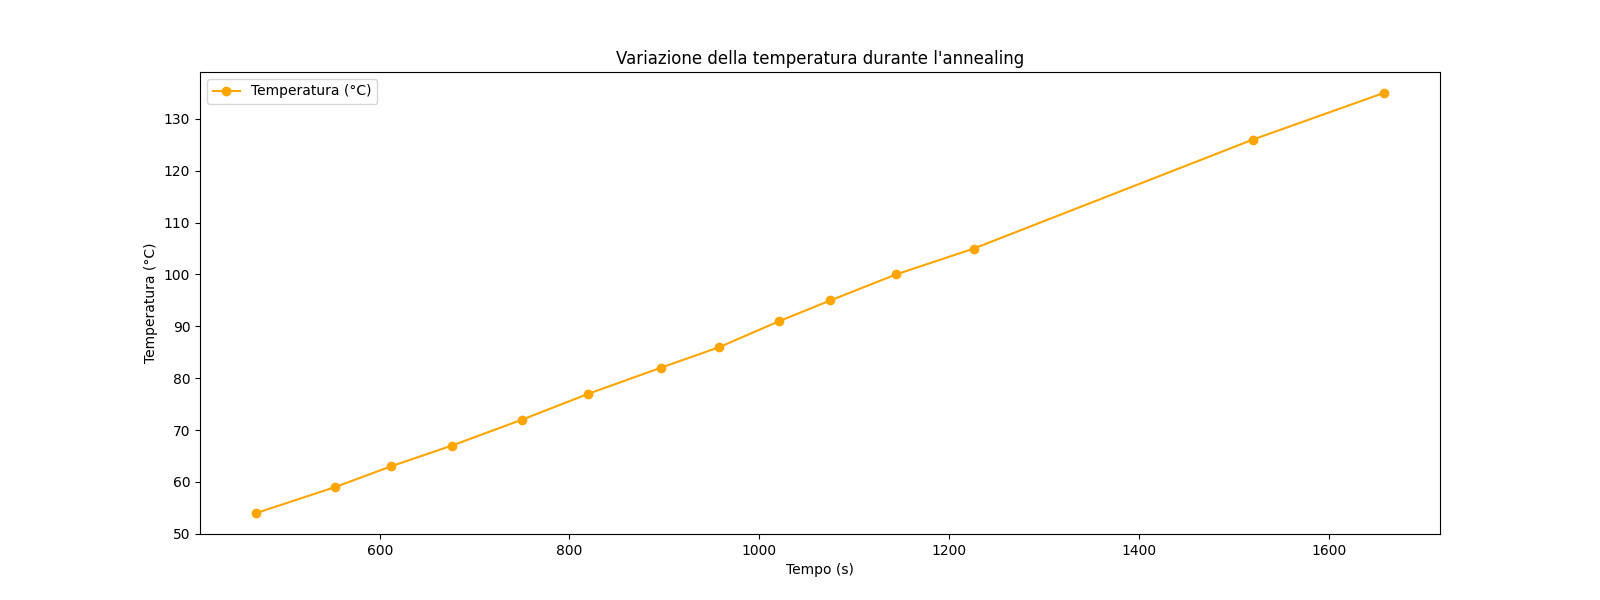

In [42]:
plt.figure(figsize=(16, 6))

plt.plot(annealing_temperature[:, 0], annealing_temperature[:, 1], label='Temperatura (°C)', color='orange', marker="o")
plt.xlabel('Tempo (s)')
plt.ylabel('Temperatura (°C)')
plt.title('Variazione della temperatura durante l\'annealing')
plt.legend()
plt.show()

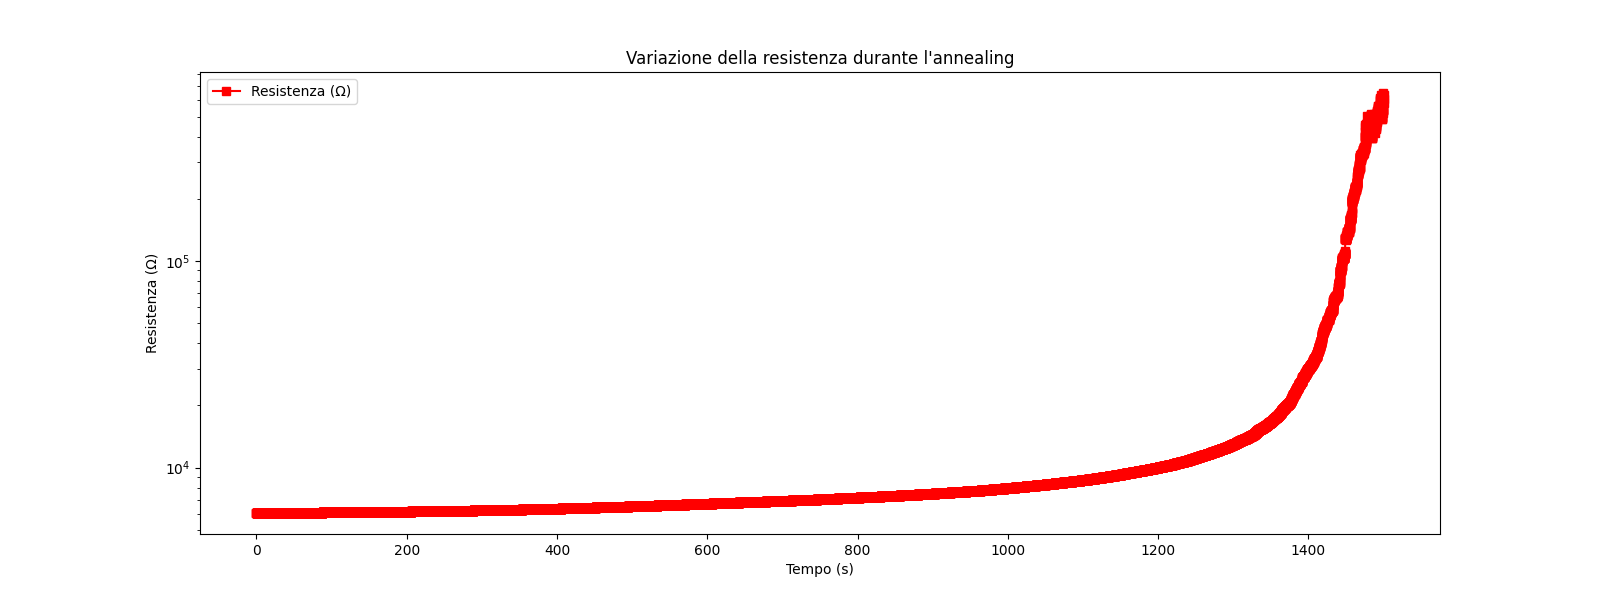

In [52]:
plt.figure(figsize=(16, 6))


zero_reistence_mask = annealing_resistence[:, 1] == 0.0
annealing_resistence = annealing_resistence[~zero_reistence_mask]  # rimuove i valori di resistenza a 0.0 per evitare problemi con la scala logaritmica

insulator_time = 1500
insulator_mask = annealing_resistence[:, 0] < insulator_time

non_insulator_data = annealing_resistence[insulator_mask]
non_insulator_resistence = non_insulator_data[:, 1]
non_insulator_time = non_insulator_data[:, 0]

#plt.plot(annealing_resistence[:, 0][insulator_mask], annealing_resistence[:, 1][insulator_mask], label='Resistenza (Ω)', color='blue', marker="o")
plt.plot(non_insulator_time, non_insulator_resistence, label='Resistenza (Ω)', color='red', marker="s")

plt.xlabel('Tempo (s)')
plt.ylabel('Resistenza (Ω)')
plt.yscale('log')
plt.title('Variazione della resistenza durante l\'annealing')
plt.legend()
plt.show()

In [53]:
interpolated_temperature = np.interp(non_insulator_time, annealing_temperature[:, 0], annealing_temperature[:, 1])  # interpolazione della temperatura per avere valori corrispondenti ai tempi della resistenza

In [68]:
linear_regime_end_time = 800
linear_regime_start_time = 600
linear_regime_mask = (non_insulator_time <= linear_regime_end_time) & (non_insulator_time >= linear_regime_start_time)


linear_regime_temp = interpolated_temperature[linear_regime_mask]

linear_regime_resistence = non_insulator_resistence[linear_regime_mask]
linear_regime_time = non_insulator_time[linear_regime_mask]


In [69]:
temp_m, temp_q = np.polyfit(linear_regime_temp, linear_regime_resistence, 1)
linear_incread_func = lambda T: temp_m * T + temp_q

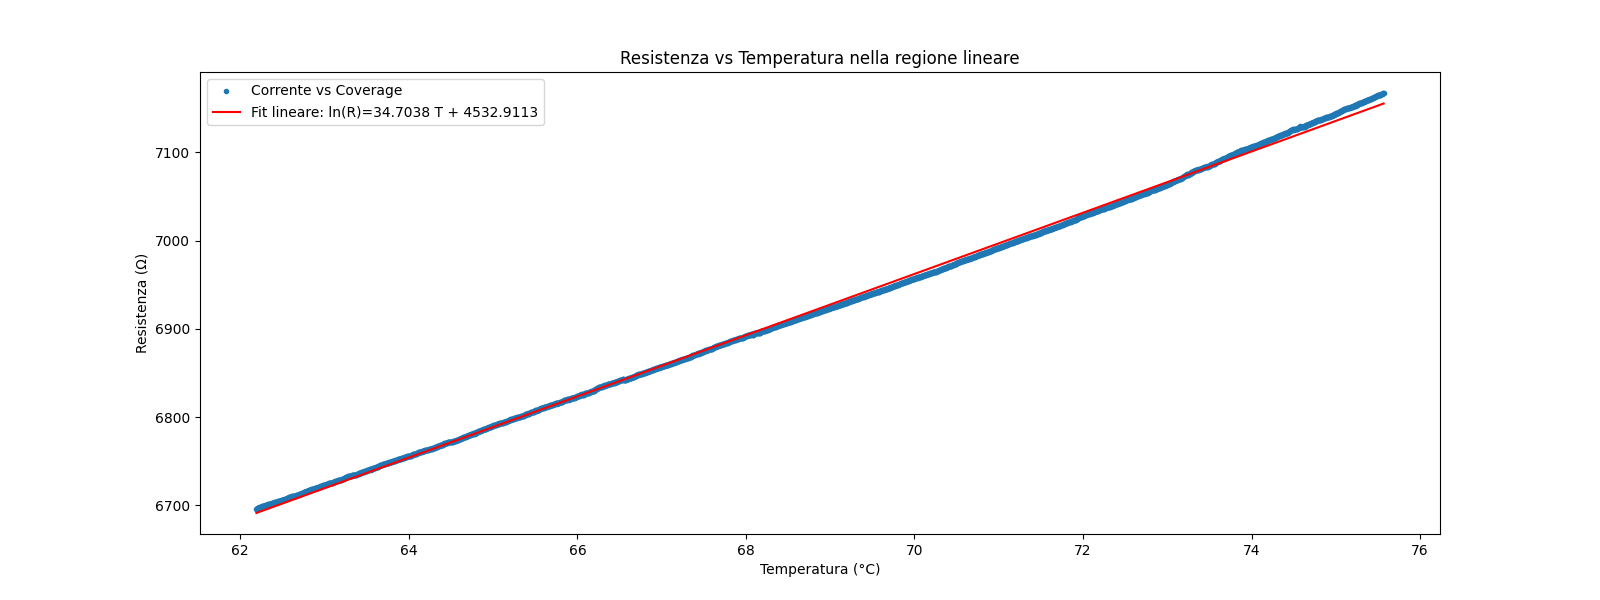

In [70]:
plt.figure(figsize=(16, 6))

plt.plot(linear_regime_temp, linear_regime_resistence, label='Corrente vs Coverage', marker='o', markersize=3, linestyle='none')
plt.plot(linear_regime_temp, linear_incread_func(linear_regime_temp), label=f'Fit lineare: ln(R)={temp_m:.4f} T + {temp_q:.4f}', color='red')

plt.xlabel('Temperatura (°C)')
plt.ylabel('Resistenza (Ω)')
plt.title('Resistenza vs Temperatura nella regione lineare')
plt.legend()
plt.show()


In [71]:
non_linear_mask = (non_insulator_time > linear_regime_end_time)
non_linear_temp = interpolated_temperature[non_linear_mask]
non_linear_resistence = non_insulator_resistence[non_linear_mask]
non_linear_time = non_insulator_time[non_linear_mask]

resistence_without_linear_contribution = non_linear_resistence - linear_incread_func(non_linear_temp)

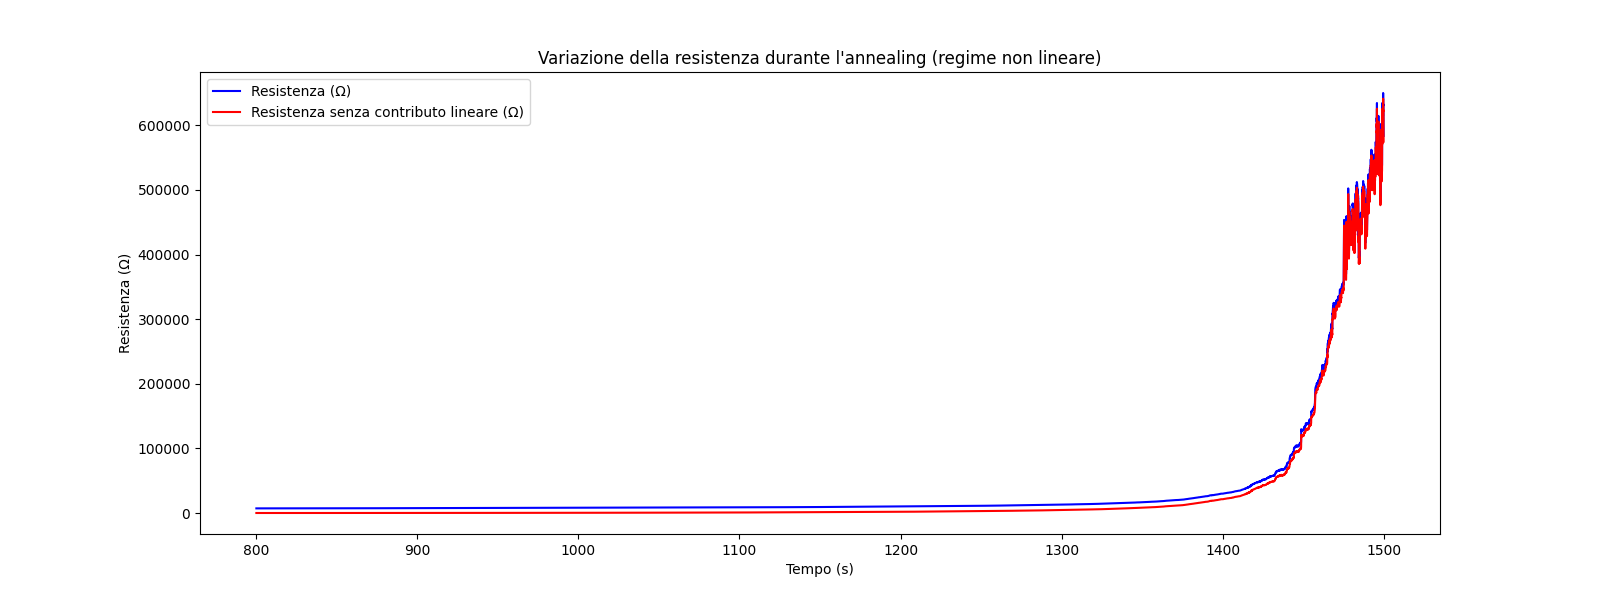

In [72]:
plt.figure(figsize=(16, 6))

plt.plot(non_linear_time, non_linear_resistence, label='Resistenza (Ω)', color='blue')
plt.plot(non_linear_time, resistence_without_linear_contribution, label='Resistenza senza contributo lineare (Ω)', color='red')
plt.xlabel('Tempo (s)')
plt.ylabel('Resistenza (Ω)')
plt.title('Variazione della resistenza durante l\'annealing (regime non lineare)')
plt.legend()
plt.show()  


Fit percolativo: A=5.3994e+07, tc=1489.17


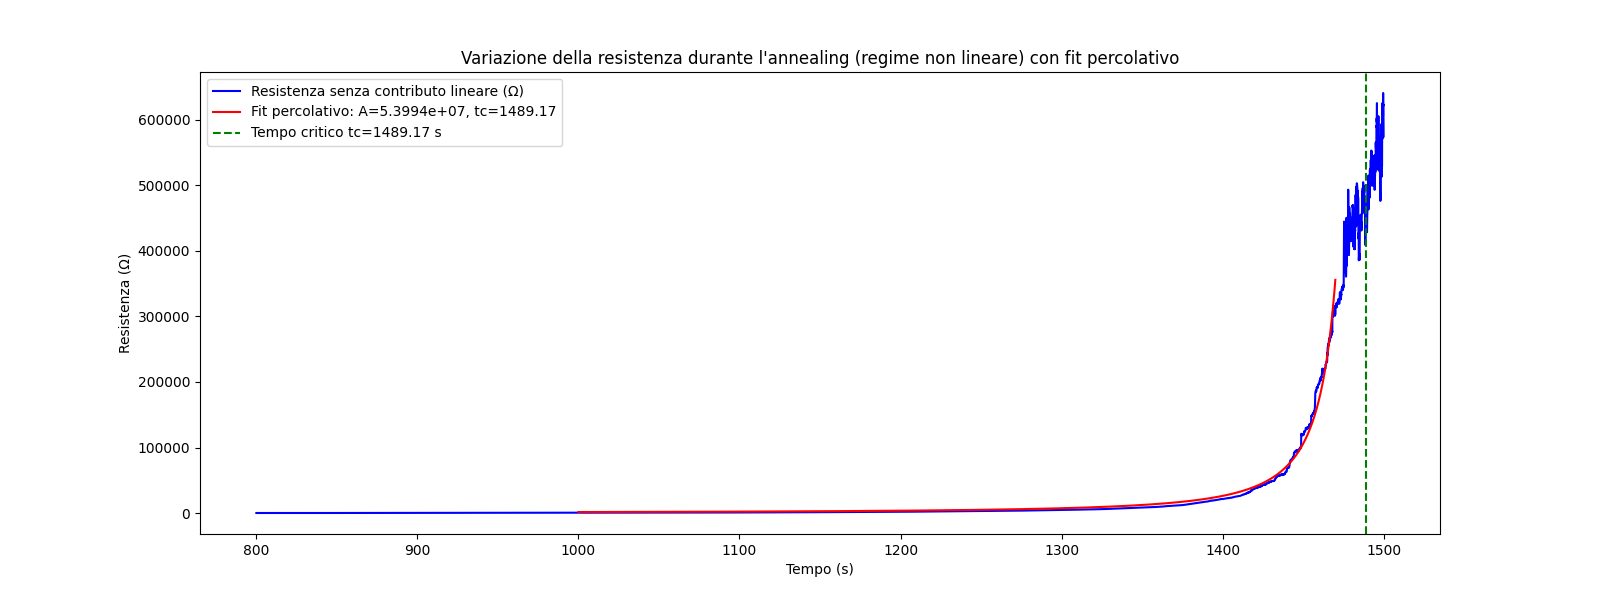

In [123]:
fit_data_mask = (non_linear_time >= 1000) & (non_linear_time <= 1470)

p = 1.7 # fissato prima e dovrebbe essere universale

def resistence_model_percolation(t, A, tc):
    # un modello percolativo "al contrario", dove la resistenza diverge al tempo critico tc, con un esponente p fissato dalla curva percolativa di prima
    return A / (tc - t)**p

popt_percolation, pcov_percolation = sp.optimize.curve_fit(resistence_model_percolation, non_linear_time[fit_data_mask], resistence_without_linear_contribution[fit_data_mask], p0=[1e-3, 1500], bounds=([0, 1470], [np.inf, 2000]))

print(f"Fit percolativo: A={popt_percolation[0]:.4e}, tc={popt_percolation[1]:.2f}")

plt.figure(figsize=(16, 6))

plt.plot(non_linear_time, resistence_without_linear_contribution, label='Resistenza senza contributo lineare (Ω)', color='blue')
plt.plot(non_linear_time[fit_data_mask], resistence_model_percolation(non_linear_time[fit_data_mask], *popt_percolation), label=f'Fit percolativo: A={popt_percolation[0]:.4e}, tc={popt_percolation[1]:.2f}', color='red')

plt.axvline(popt_percolation[1], color='green', linestyle='--', label=f'Tempo critico tc={popt_percolation[1]:.2f} s')

plt.xlabel('Tempo (s)')
plt.ylabel('Resistenza (Ω)')
plt.title('Variazione della resistenza durante l\'annealing (regime non lineare) con fit percolativo')
plt.legend()
plt.show()


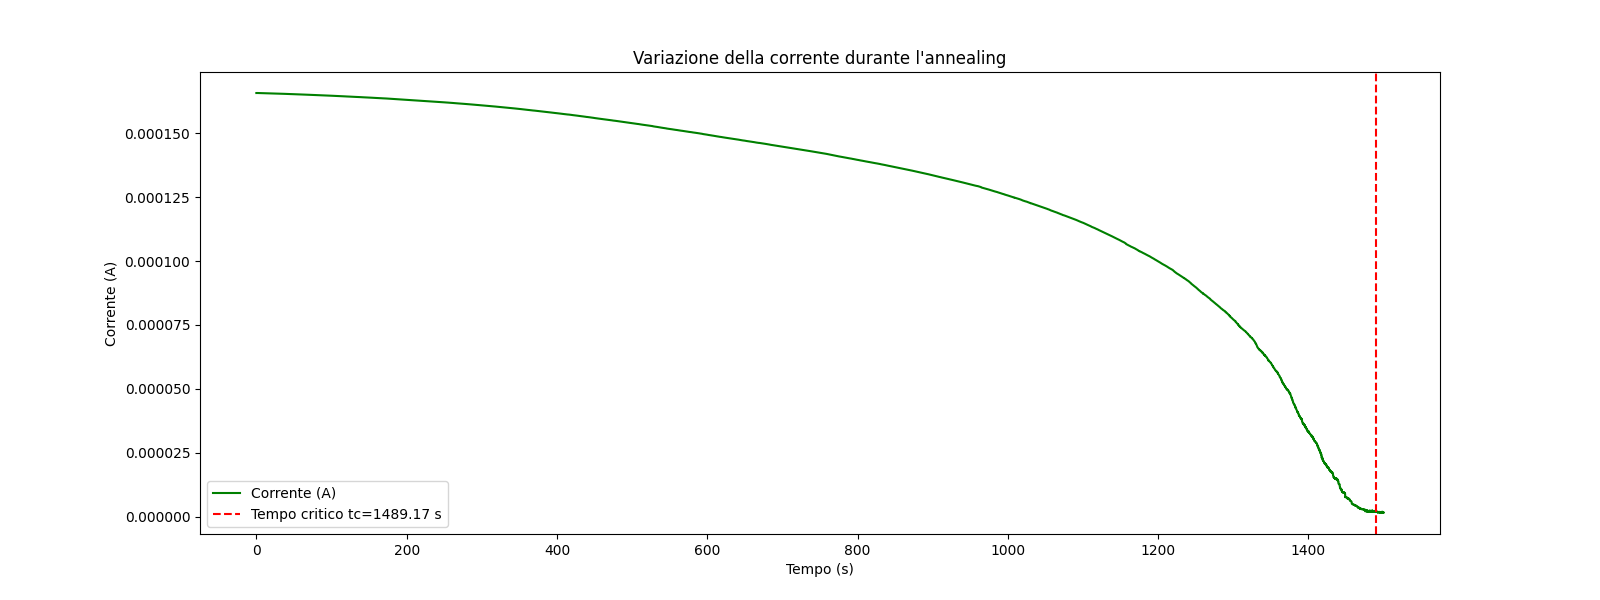

In [120]:
annealing_currents = 1 / non_insulator_resistence  # calcolo della corrente come inverso della resistenza
plt.figure(figsize=(16, 6))
plt.plot(non_insulator_time, annealing_currents, label='Corrente (A)', color='green')
plt.axvline(popt_percolation[1], color='red', linestyle='--', label=f'Tempo critico tc={popt_percolation[1]:.2f} s')
plt.xlabel('Tempo (s)')
plt.ylabel('Corrente (A)')
plt.title('Variazione della corrente durante l\'annealing')
plt.legend()
plt.show()

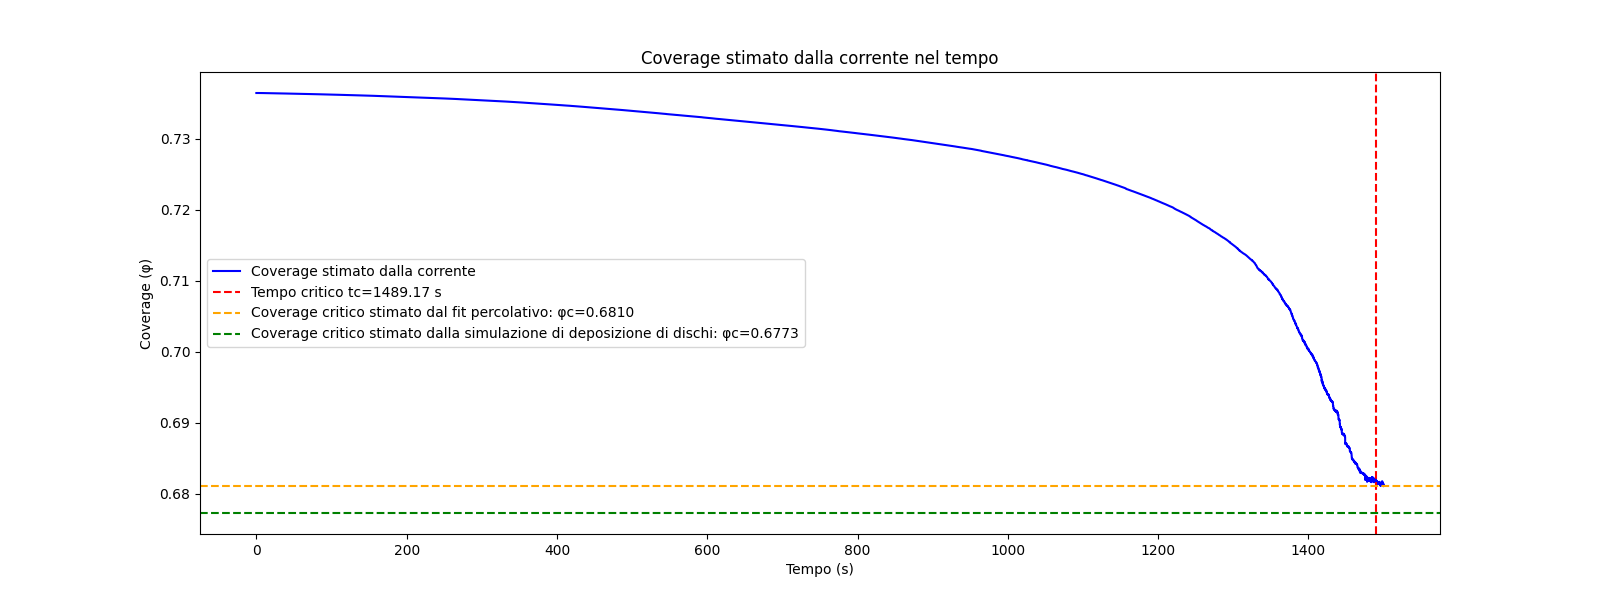

In [127]:
phis = calculate_coverage_from_current(annealing_currents)  # calcolo del coverage stimato dalla corrente usando la funzione definita sopra

plt.figure(figsize=(16, 6))
plt.plot(non_insulator_time, phis, label='Coverage stimato dalla corrente', color='blue')

plt.axvline(popt_percolation[1], color='red', linestyle='--', label=f'Tempo critico tc={popt_percolation[1]:.2f} s')

closest_phi_index = np.argmin(np.abs(phis - PHI_C))
plt.axhline(phis[closest_phi_index], color='orange', linestyle='--', label=f'Coverage critico stimato dal fit percolativo: φc={phis[closest_phi_index]:.4f}')

plt.axhline(PHI_C, color='green', linestyle='--', label=f'Coverage critico stimato dalla simulazione di deposizione di dischi: φc={PHI_C:.4f}')

plt.xlabel('Tempo (s)')
plt.ylabel('Coverage (φ)')
plt.title('Coverage stimato dalla corrente nel tempo')
plt.legend()
plt.show()